### Cell 1- Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy.stats import randint, uniform, loguniform, spearmanr
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, make_scorer, confusion_matrix,
                             cohen_kappa_score)
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
import joblib
import os

# Constants
RANDOM_STATE = 42
N_CLASSES = None
SCALED_MODELS = {'SVM', 'LogisticRegression'}
CLASS_MAP = None

os.makedirs("output", exist_ok=True)
os.makedirs("final_models", exist_ok=True)

### Cell 2 - Load Data

In [2]:
# Option 1: Google Colab (uncomment if running in Colab)
from google.colab import files
uploaded = files.upload()

# Option 2: Local file (uncomment if running locally)
df = pd.read_csv("final_processed_data.csv")

X = df.drop(columns=['target_fertilizer'])
y = df['target_fertilizer']

# Infer class mappings
unique_classes = sorted(y.unique())
N_CLASSES = len(unique_classes)
CLASS_MAP = {i: cls for i, cls in enumerate(unique_classes)}

print(f"Shape: {X.shape}")
print(f"Number of classes: {N_CLASSES}")
print(f"Class distribution:{y.value_counts().sort_index()}")

Saving final_processed_data.csv to final_processed_data.csv
Shape: (3100, 44)
Number of classes: 10
Class distribution:target_fertilizer
0     157
1     375
2    1054
3      31
4      52
5     181
6     326
7      95
8     154
9     675
Name: count, dtype: int64


### Cell 3 — Split Data

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

### Cell 4 — Imbalance Handling - Sample Weights

In [4]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

### Cell 5— Scale Data

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep scaled data as numpy arrays for SHAP
X_train_arr = X_train.values
X_test_arr = X_test.values

### Cell 6 — CV + Metric

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_macro = make_scorer(f1_score, average='macro')

### Cell 7 — Models

In [7]:
models = {
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss"),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    "SVM": SVC(probability=True),
    "LogisticRegression": LogisticRegression(max_iter=1000)
}

### Cell 8 - RandomizedSearchCV Param Distributions

In [8]:
param_distributions = {

    "RandomForest": {
        "n_estimators": randint(250, 500),
        "max_depth": [10, 12, 14, 16, None],
        "min_samples_split": randint(10, 20),
        "min_samples_leaf": randint(1, 4),
        "max_features": [None, 'sqrt', 'log2']
    },

    "GradientBoosting": {
        "n_estimators": randint(600, 1000),
        "learning_rate": uniform(0.05, 0.1),
        "max_depth": randint(4, 7),
        "subsample": uniform(0.7, 0.3),
        "max_features": [None, 'sqrt', 'log2'],
        "min_samples_leaf": randint(4, 10),
        "min_samples_split": randint(2, 6)
    },

    "XGBoost": {
        "n_estimators": randint(300, 600),
        "learning_rate": uniform(0.02, 0.08),
        "max_depth": randint(6, 10),
        "subsample": uniform(0.7, 0.3),
        "colsample_bytree": uniform(0.7, 0.3),
        "min_child_weight": randint(8, 18),
        "gamma": uniform(1.0, 3.0),
        "reg_alpha": loguniform(1e-4, 1.0),
        "reg_lambda": loguniform(1e-3, 10.0)
    },

    "LightGBM": {
        "n_estimators": randint(300, 700),
        "learning_rate": uniform(0.005, 0.03),
        "max_depth": randint(4, 8),
        "num_leaves": randint(60, 120),
        "subsample": uniform(0.6, 0.3),
        "colsample_bytree": uniform(0.5, 0.3),
        "min_child_samples": randint(10, 40),
        "reg_alpha": loguniform(1e-2, 10.0),
        "reg_lambda": loguniform(1e-2, 10.0)
    },

    "SVM": {
        "kernel": ['linear'],
        "C": loguniform(1.0, 100.0)
    },

    "LogisticRegression": {
        "solver": ['saga'],
        "penalty": ['l1'],
        "C": loguniform(0.1, 10.0)
    }
}

### Cell 9 — Random Search Execution

In [9]:
best_params = {}

for name, model in models.items():
    print(f"Random Search for {name}")

    search = RandomizedSearchCV(
        model,
        param_distributions[name],
        n_iter=30,
        scoring=f1_macro,
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )

    if name in SCALED_MODELS:
        search.fit(X_train_scaled, y_train)
    else:
        search.fit(X_train, y_train, sample_weight=sample_weights)

    best_params[name] = search.best_params_

    print(f"✅ Best Params for {name}: {search.best_params_}")

Random Search for RandomForest
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best Params for RandomForest: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 13, 'n_estimators': 341}
Random Search for GradientBoosting
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best Params for GradientBoosting: {'learning_rate': np.float64(0.1406828441545754), 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 3, 'n_estimators': 720, 'subsample': np.float64(0.9454044297767479)}
Random Search for XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ Best Params for XGBoost: {'colsample_bytree': np.float64(0.8001125833417065), 'gamma': np.float64(1.4286004537658223), 'learning_rate': np.float64(0.07207107783590823), 'max_depth': 6, 'min_child_weight': 9, 'n_estimators': 593, 'reg_alpha': np.float64(0.00010071984838809202), 'reg_lambda': np.float64(9.307782732027235), 'subsample': np.flo

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Print Best Params

In [10]:
print(best_params)

{'RandomForest': {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 13, 'n_estimators': 341}, 'GradientBoosting': {'learning_rate': np.float64(0.1406828441545754), 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 6, 'min_samples_split': 3, 'n_estimators': 720, 'subsample': np.float64(0.9454044297767479)}, 'XGBoost': {'colsample_bytree': np.float64(0.8001125833417065), 'gamma': np.float64(1.4286004537658223), 'learning_rate': np.float64(0.07207107783590823), 'max_depth': 6, 'min_child_weight': 9, 'n_estimators': 593, 'reg_alpha': np.float64(0.00010071984838809202), 'reg_lambda': np.float64(9.307782732027235), 'subsample': np.float64(0.8852444528883149)}, 'LightGBM': {'colsample_bytree': np.float64(0.5596527212266416), 'learning_rate': np.float64(0.0263402585824595), 'max_depth': 6, 'min_child_samples': 10, 'n_estimators': 678, 'num_leaves': 64, 'reg_alpha': np.float64(6.010389754773889), 'reg_lambda': np.float64(0.8979064194712973), 'subsample':

### Cell 10 - Train/Val split for early stopping

In [11]:
X_tr, X_val, y_tr, y_val, sw_tr, sw_val = train_test_split(
    X_train,
    y_train,
    sample_weights,
    test_size=0.15,
    stratify=y_train,
    random_state=RANDOM_STATE
)

X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

### Cell 11 — Build Model + Setup

In [15]:
def build_model(name, params):
    if name == 'RandomForest':
        return RandomForestClassifier(**params, n_jobs=-1, random_state=RANDOM_STATE)

    elif name == 'GradientBoosting':
        return GradientBoostingClassifier(**params, random_state=RANDOM_STATE)

    elif name == 'XGBoost':
        # Move early stopping to initialization for better version compatibility
        return XGBClassifier(**params, n_jobs=-1, eval_metric='mlogloss',
                             tree_method='hist', random_state=RANDOM_STATE,
                             early_stopping_rounds=50)

    elif name == 'LightGBM':
        return LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)

    elif name == 'SVM':
        return SVC(**params, probability=True)

    elif name == 'LogisticRegression':
        return LogisticRegression(**params, max_iter=1000)

### Cell 12 — Final Training (Early Stopping)

In [16]:
import xgboost as xgb

final_models = {}
results = []

for name in best_params.keys():
    print(f"🚀 Training {name}")

    model = build_model(name, best_params[name])

    if name in SCALED_MODELS:
        X_train_use, X_val_use, X_test_use = X_tr_scaled, X_val_scaled, X_test_scaled
    else:
        X_train_use, X_val_use, X_test_use = X_tr, X_val, X_test

    if name == "XGBoost":
        # early_stopping_rounds is now handled in build_model constructor
        model.fit(X_train_use, y_tr,
                  sample_weight=sw_tr,
                  eval_set=[(X_val_use, y_val)],
                  verbose=False)

    elif name == "LightGBM":
        model.fit(X_train_use, y_tr,
                  sample_weight=sw_tr,
                  eval_set=[(X_val_use, y_val)],
                  eval_sample_weight=[sw_val],
                  callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

    else:
        model.fit(X_train_use, y_tr, sample_weight=sw_tr)

    y_pred = model.predict(X_test_use)

    # Calculate all metrics
    results.append({
        "Model": name,
        "F1_Macro": f1_score(y_test, y_pred, average='macro'),
        "F1_Weighted": f1_score(y_test, y_pred, average='weighted'),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_Macro": precision_score(y_test, y_pred, average='macro', zero_division=0),
        "Precision_Weighted": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall_Macro": recall_score(y_test, y_pred, average='macro', zero_division=0),
        "Recall_Weighted": recall_score(y_test, y_pred, average='weighted', zero_division=0)
    })

    final_models[name] = model

🚀 Training RandomForest
🚀 Training GradientBoosting
🚀 Training XGBoost
🚀 Training LightGBM
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[678]	valid_0's multi_logloss: 0.222555
🚀 Training SVM
🚀 Training LogisticRegression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Cell 13 - Results

In [17]:
results_df = pd.DataFrame(results).sort_values("F1_Macro", ascending=False)
print(results_df)

                Model  F1_Macro  F1_Weighted  Accuracy  Precision_Macro  \
1    GradientBoosting  0.934541     0.946841  0.946774         0.916361   
0        RandomForest  0.925131     0.943864  0.943548         0.904638   
3            LightGBM  0.919028     0.933872  0.933871         0.888328   
2             XGBoost  0.906793     0.930792  0.930645         0.882561   
4                 SVM  0.681660     0.784656  0.780645         0.675029   
5  LogisticRegression  0.625414     0.712204  0.698387         0.586479   

   Precision_Weighted  Recall_Macro  Recall_Weighted  
1            0.950061      0.959020         0.946774  
0            0.948385      0.956149         0.943548  
3            0.939477      0.961717         0.933871  
2            0.936805      0.943740         0.930645  
4            0.797751      0.701016         0.780645  
5            0.752937      0.720959         0.698387  


### Cell 14 - Save models

In [18]:
for name, model in final_models.items():
    joblib.dump(model, f"final_models/{name}.joblib")

print("✅ Models saved to final_models/")

✅ Models saved to final_models/


### Cell 15 - Visualize Results

/tmp/ipykernel_8919/3733992630.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
/tmp/ipykernel_8919/3733992630.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')


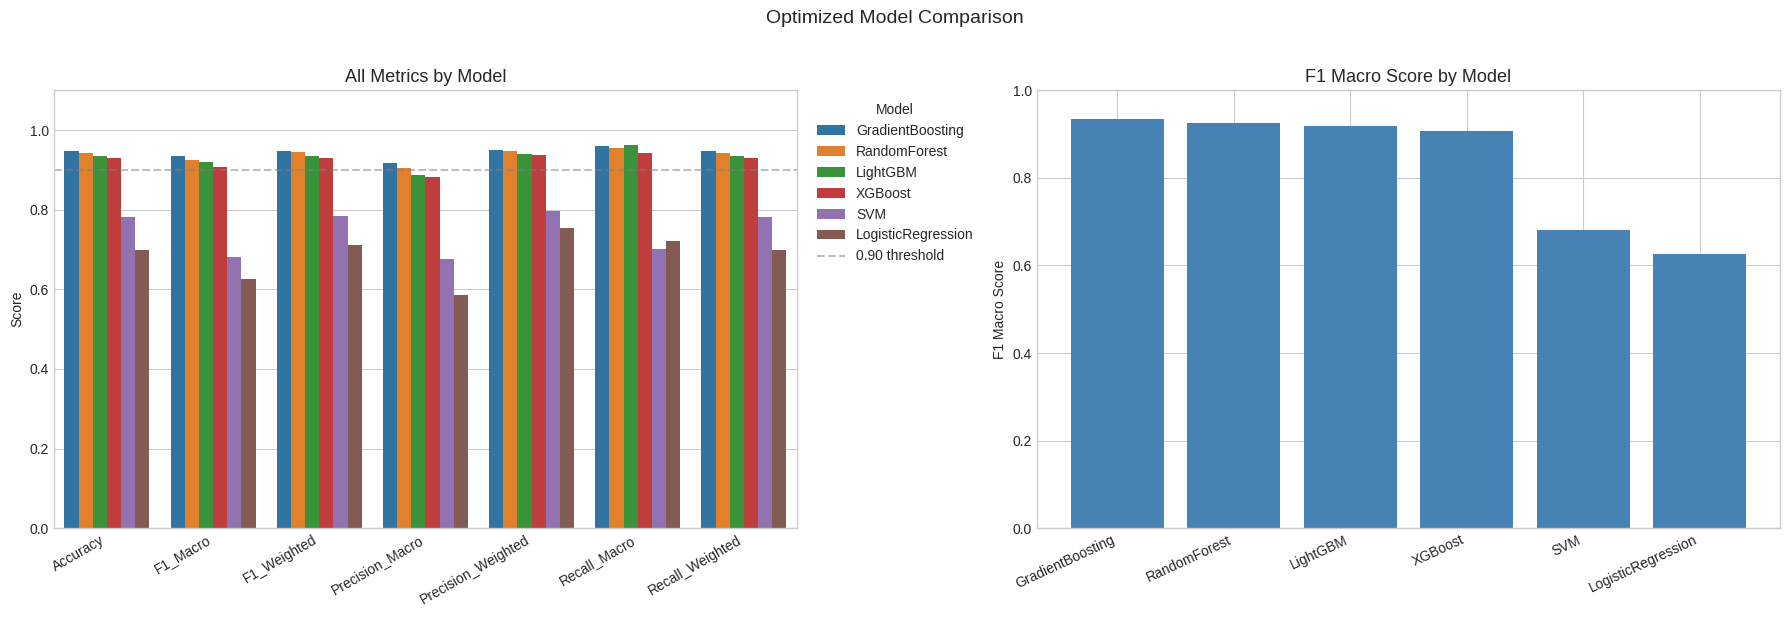

✓ Results saved.


In [19]:
plt.style.use('seaborn-v0_8-whitegrid')

METRIC_COLS = ['Accuracy', 'F1_Macro', 'F1_Weighted',
               'Precision_Macro', 'Precision_Weighted',
               'Recall_Macro', 'Recall_Weighted']

plot_df = results_df.melt(id_vars=['Model'], value_vars=METRIC_COLS,
                          var_name='Metric', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='tab10', ax=axes[0])
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.90 threshold')
axes[0].set_title('All Metrics by Model', fontsize=13)
axes[0].set_ylim(0, 1.1)
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')

axes[1].bar(results_df['Model'], results_df['F1_Macro'], color='steelblue')
axes[1].set_title('F1 Macro Score by Model', fontsize=13)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')
axes[1].set_xlabel('')
axes[1].set_ylabel('F1 Macro Score')
axes[1].set_ylim(0, 1.0)

plt.suptitle('Optimized Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output/optimized_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

results_df.to_csv('output/optimized_model_results.csv', index=False)
print("✓ Results saved.")

### Cell 16 - Per-Class Performance & Confusion Matrix

PER-CLASS METRICS — Best Model: GradientBoosting
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        31
           1       0.93      0.89      0.91        75
           2       1.00      0.93      0.97       211
           3       0.75      1.00      0.86         6
           4       0.91      0.91      0.91        11
           5       0.95      1.00      0.97        36
           6       0.95      0.86      0.90        65
           7       0.90      1.00      0.95        19
           8       1.00      1.00      1.00        31
           9       0.91      0.99      0.95       135

    accuracy                           0.95       620
   macro avg       0.92      0.96      0.93       620
weighted avg       0.95      0.95      0.95       620

☁—  Classes with Recall < 0.80:


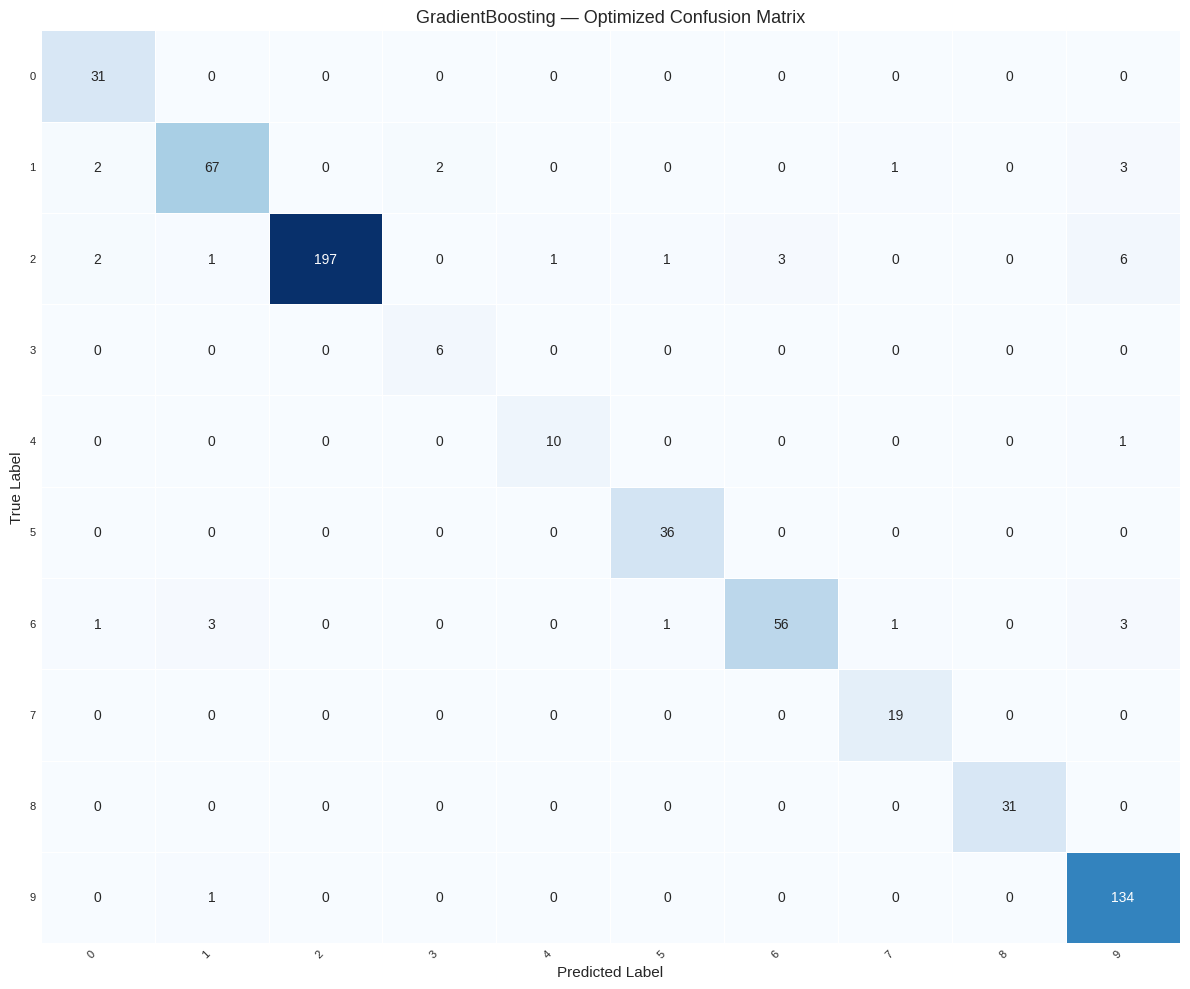

In [21]:
best_name  = results_df.iloc[0]['Model']
best_model = final_models[best_name]

# Fix: GradientBoosting usually expects a DataFrame to keep feature names if trained on one
X_te_best = X_test_scaled if best_name in SCALED_MODELS else X_test

y_pred_best  = best_model.predict(X_te_best)
# Fix: Ensure target_names are strings to avoid TypeError in classification_report
target_names = [str(CLASS_MAP[i]) for i in range(N_CLASSES)]

print("=" * 70)
print(f"PER-CLASS METRICS — Best Model: {best_name}")
print("=" * 70)
print(classification_report(y_test, y_pred_best, target_names=target_names, zero_division=0))

recalls      = pd.Series(recall_score(y_test, y_pred_best, average=None, zero_division=0), index=target_names)
CLASS_MAP_INV = {v: k for k, v in CLASS_MAP.items()}

print("☁—  Classes with Recall < 0.80:")
for cls, rec in recalls[recalls < 0.80].items():
    # Get the original key (int) for counting
    original_key = list(CLASS_MAP.keys())[list(CLASS_MAP.values()).index(np.int64(cls) if cls.isdigit() else cls)]
    n_train = np.sum(y_train == original_key)
    print(f"   • {cls} | Recall: {rec:.3f} | Train samples: {n_train}")

cm    = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            cbar=False, xticklabels=target_names, yticklabels=target_names)
plt.title(f'{best_name} — Optimized Confusion Matrix', fontsize=13)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('output/cm_optimized_best.png', dpi=150)
plt.show()

### Cell 17 - Compute SHAP Values

In [23]:
import warnings
feature_names = X_test.columns.tolist()
feature_arr   = np.array(feature_names)
shap_values   = {}
explainers    = {}

TREE_MODELS   = {'RandomForest', 'XGBoost', 'LightGBM'}
GB_MODELS     = {'GradientBoosting'}
LINEAR_MODELS = {'LogisticRegression'}
KERNEL_MODELS = {'SVM'}

for name, model in final_models.items():
    print(f"⏳ Computing SHAP for {name}...")

    # Suppress internal sklearn warnings about feature names during SHAP loops
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="X does not have valid feature names")

        if name in TREE_MODELS:
            explainer = shap.TreeExplainer(model)
            sv = explainer.shap_values(X_test_arr)
            shap_values[name] = sv

        elif name in GB_MODELS:
            # Use the DataFrame subset for background to preserve feature names
            background = shap.sample(X_test, 100, random_state=RANDOM_STATE)
            explainer  = shap.Explainer(model.predict_proba, background, feature_names=feature_names)
            sv = explainer(X_test.values)
            shap_values[name] = sv.values

        elif name in LINEAR_MODELS:
            masker    = shap.maskers.Independent(X_train_scaled, max_samples=200)
            explainer = shap.LinearExplainer(model, masker)
            sv = explainer(X_test_scaled)
            shap_values[name] = sv.values

        elif name in KERNEL_MODELS:
            print(f"   ⚠ KernelExplainer is slow — using 50-sample subsample for {name}.")
            background = shap.sample(X_train_scaled, 50, random_state=RANDOM_STATE)
            explainer  = shap.KernelExplainer(model.predict_proba, background)
            rng        = np.random.RandomState(RANDOM_STATE)
            sample_idx = rng.choice(len(X_test_scaled), 50, replace=False)
            sv = explainer.shap_values(X_test_scaled[sample_idx])
            shap_values[name] = sv

    explainers[name] = explainer
    print(f"✓ SHAP done for {name}")

def get_mean_abs_shap(sv):
    if isinstance(sv, list):
        return np.mean([np.abs(c).mean(axis=0) for c in sv], axis=0)
    arr = np.array(sv)
    if arr.ndim == 3:
        return np.abs(arr).mean(axis=(0, 2))
    return np.abs(arr).mean(axis=0)

⏳ Computing SHAP for RandomForest...
✓ SHAP done for RandomForest
⏳ Computing SHAP for GradientBoosting...


PermutationExplainer explainer: 621it [08:48,  1.16it/s]


✓ SHAP done for GradientBoosting
⏳ Computing SHAP for XGBoost...
✓ SHAP done for XGBoost
⏳ Computing SHAP for LightGBM...
✓ SHAP done for LightGBM
⏳ Computing SHAP for SVM...
   ⚠ KernelExplainer is slow — using 50-sample subsample for SVM.


  0%|          | 0/50 [00:00<?, ?it/s]

✓ SHAP done for SVM
⏳ Computing SHAP for LogisticRegression...
✓ SHAP done for LogisticRegression


### SHAP Feature Importance: All Models Grid

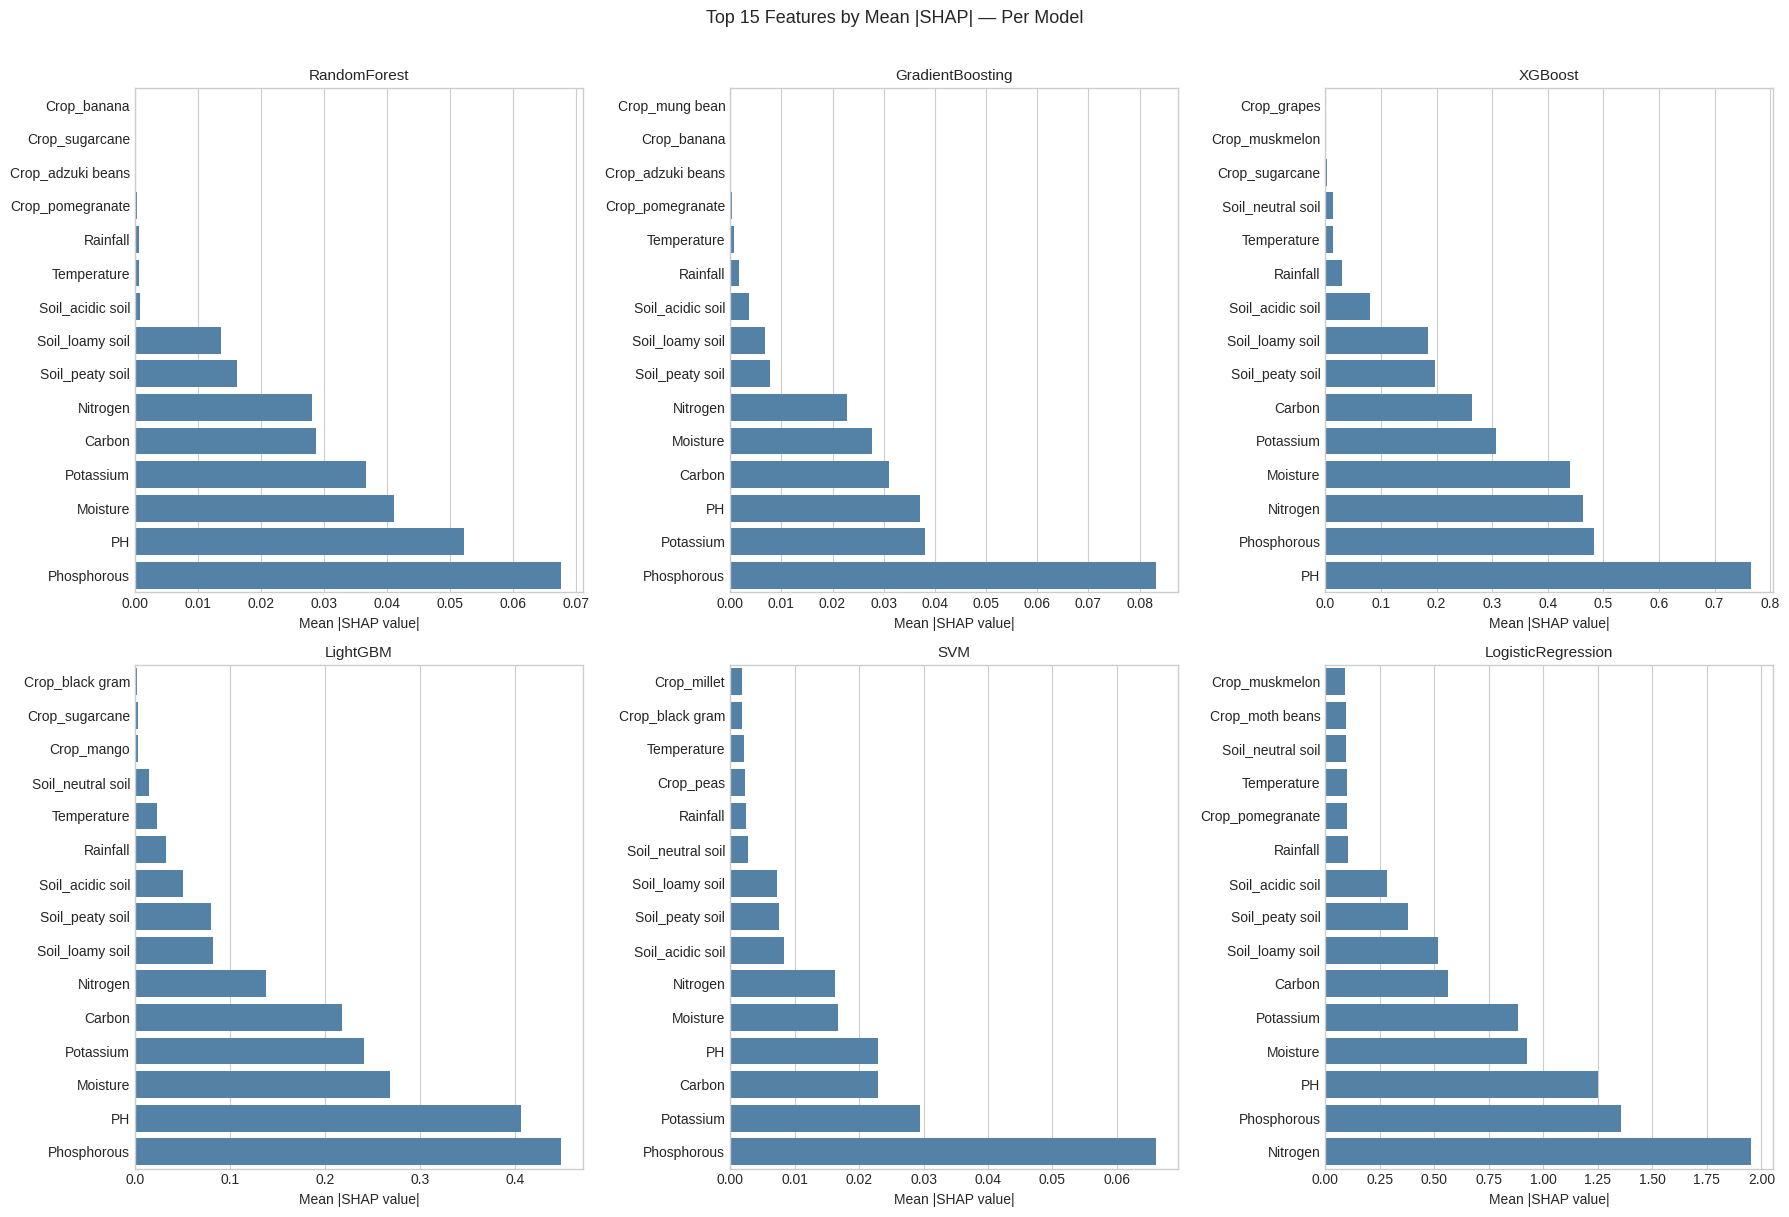

In [24]:
n_models = len(shap_values)
n_cols   = 3
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for i, (name, sv) in enumerate(shap_values.items()):
    ax = axes[i]
    mean_abs = get_mean_abs_shap(sv)
    top_idx  = np.argsort(mean_abs)[-15:]

    shap_df  = pd.DataFrame({
        'Feature':     [feature_names[idx] for idx in top_idx],
        'Mean |SHAP|': mean_abs[top_idx],
    }).sort_values('Mean |SHAP|')

    sns.barplot(data=shap_df, x='Mean |SHAP|', y='Feature', color='steelblue', ax=ax)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 15 Features by Mean |SHAP| — Per Model', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('output/shap_importance_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP Feature Importance: Best Model

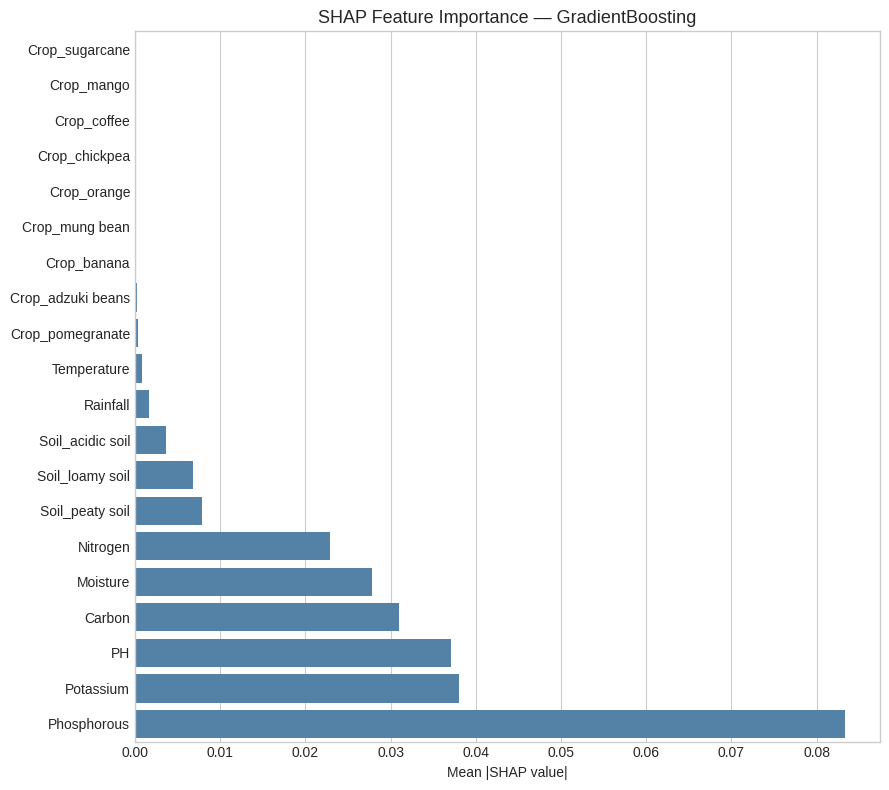

In [25]:
mean_abs_best = get_mean_abs_shap(shap_values[best_name])
top_idx       = np.argsort(mean_abs_best)[-20:]

shap_df = pd.DataFrame({
    'Feature':     feature_arr[top_idx],
    'Mean |SHAP|': mean_abs_best[top_idx],
}).sort_values('Mean |SHAP|')

plt.figure(figsize=(9, 8))
sns.barplot(data=shap_df, x='Mean |SHAP|', y='Feature', color='steelblue')
plt.title(f'SHAP Feature Importance — {best_name}', fontsize=13)
plt.xlabel('Mean |SHAP value|')
plt.ylabel('')
plt.tight_layout()
plt.savefig('output/shap_summary_best.png', dpi=150, bbox_inches='tight')
plt.show()

### Spearman Rank Correlation of Feature Importances

In [26]:
importance_dict = {name: get_mean_abs_shap(sv) for name, sv in shap_values.items()}
importance_df   = pd.DataFrame(importance_dict, index=feature_names)
model_names     = list(importance_dict.keys())

print("📐 Spearman Rank Correlation of Feature Importances:")
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        corr, pval = spearmanr(importance_df[model_names[i]], importance_df[model_names[j]])
        print(f"   {model_names[i]} ↔ {model_names[j]}: ρ = {corr:.3f} (p={pval:.3e})")

📐 Spearman Rank Correlation of Feature Importances:
   RandomForest ↔ GradientBoosting: ρ = 0.868 (p=2.271e-14)
   RandomForest ↔ XGBoost: ρ = 0.715 (p=4.880e-08)
   RandomForest ↔ LightGBM: ρ = 0.564 (p=6.658e-05)
   RandomForest ↔ SVM: ρ = 0.588 (p=2.753e-05)
   RandomForest ↔ LogisticRegression: ρ = 0.563 (p=6.865e-05)
   GradientBoosting ↔ XGBoost: ρ = 0.708 (p=7.560e-08)
   GradientBoosting ↔ LightGBM: ρ = 0.661 (p=1.050e-06)
   GradientBoosting ↔ SVM: ρ = 0.706 (p=8.887e-08)
   GradientBoosting ↔ LogisticRegression: ρ = 0.637 (p=3.311e-06)
   XGBoost ↔ LightGBM: ρ = 0.772 (p=8.215e-10)
   XGBoost ↔ SVM: ρ = 0.794 (p=1.318e-10)
   XGBoost ↔ LogisticRegression: ρ = 0.758 (p=2.535e-09)
   LightGBM ↔ SVM: ρ = 0.704 (p=9.487e-08)
   LightGBM ↔ LogisticRegression: ρ = 0.753 (p=3.695e-09)
   SVM ↔ LogisticRegression: ρ = 0.676 (p=4.808e-07)


### Model Disagreement Analysis

In [27]:
preds = {}
for name, model in final_models.items():
    X_ev        = X_test_scaled if name in SCALED_MODELS else X_test_arr
    preds[name] = model.predict(X_ev)

pred_df              = pd.DataFrame(preds)
pred_df['true']      = y_test
model_names          = list(final_models.keys())
pred_df['all_agree'] = pred_df[model_names].apply(lambda row: len(set(row)) == 1, axis=1)

disagreement_rate = (~pred_df['all_agree']).mean()
disagreements     = pred_df[~pred_df['all_agree']].copy()
disagreements['any_correct'] = disagreements.apply(
    lambda r: r['true'] in [r[m] for m in model_names], axis=1
)

print(f"🔍 Samples where models disagree: {(~pred_df['all_agree']).sum()} / {len(pred_df)} ({disagreement_rate:.1%})")
print(f"   → At least one model correct: {disagreements['any_correct'].mean():.1%}")
print(f"   → All models wrong:           {(~disagreements['any_correct']).mean():.1%}")

print("📊 Disagreements by true class:")
class_counts = disagreements.groupby('true').size().sort_values(ascending=False)
if CLASS_MAP:
    class_counts.index = [CLASS_MAP[c] for c in class_counts.index]
print(class_counts.to_string())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔍 Samples where models disagree: 205 / 620 (33.1%)
   → At least one model correct: 6.3%
   → All models wrong:           93.7%
📊 Disagreements by true class:
2    28
9    11
8     4
1     2
6     2
0     1
5     1
7     1


### Pairwise Cohen's Kappa Heatmap

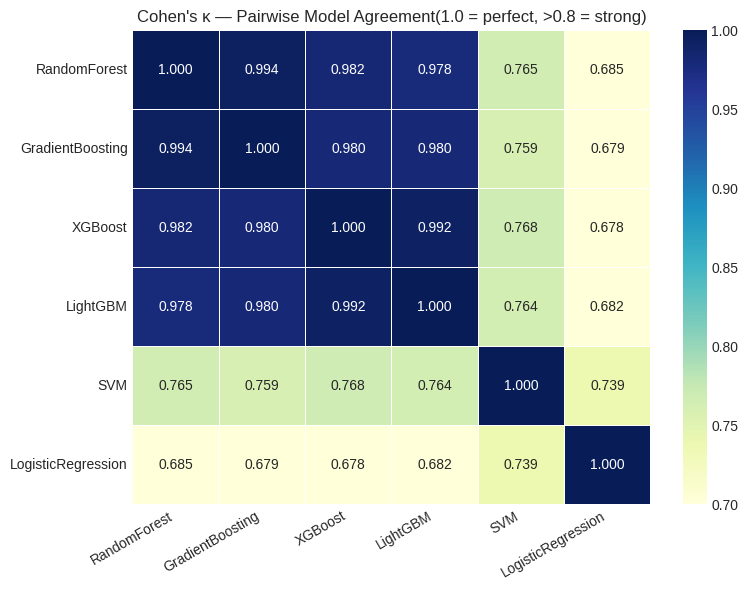

In [28]:
kappa_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
for m1 in model_names:
    for m2 in model_names:
        kappa_matrix.loc[m1, m2] = cohen_kappa_score(preds[m1], preds[m2])

plt.figure(figsize=(8, 6))
sns.heatmap(
    kappa_matrix.astype(float), annot=True, fmt='.3f',
    cmap='YlGnBu', vmin=0.7, vmax=1.0, linewidths=0.5
)
plt.title("Cohen's κ — Pairwise Model Agreement(1.0 = perfect, >0.8 = strong)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('output/model_agreement_kappa.png', dpi=150)
plt.show()